In [ ]:
#分析切分後的類別分佈
import os
import yaml
import pandas as pd

# --- 設定路徑 ---
YOLO_DATA_DIR = 'roboflow_1000_側拍_split'
DATA_YAML_PATH = os.path.join(YOLO_DATA_DIR, 'data.yaml')

# --- 函數：讀取並統計標註 ---
def count_labels(label_dir, class_names):
    """
    遍歷指定資料夾內的 .txt 標註檔，並統計:
    1. 每個類別的物件數量
    2. 純背景圖片 (空標註檔) 的數量
    """
    counts = {name: 0 for name in class_names}
    total_files = 0
    total_objects = 0
    background_files = 0
    
    if not os.path.exists(label_dir):
        print(f"⚠️ 警告：找不到路徑 {label_dir}。跳過此分割。")
        return counts, 0, 0, 0

    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            file_path = os.path.join(label_dir, filename)
            total_files += 1
            
            try:
                # 檢查是否為空檔案 (0 bytes)
                if os.path.getsize(file_path) == 0:
                    background_files += 1
                    continue

                has_objects = False
                with open(file_path, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if not line:
                            continue
                        
                        has_objects = True 
                        
                        try:
                            # YOLO 格式: <class_id> <x> <y> <w> <h>
                            class_index = int(line.split()[0])
                            
                            if 0 <= class_index < len(class_names):
                                class_name = class_names[class_index]
                                counts[class_name] += 1
                                total_objects += 1
                        except (ValueError, IndexError):
                            continue 
                
                if not has_objects:
                    background_files += 1
                                    
            except Exception as e:
                print(f"❌ 錯誤：讀取標註檔 {filename} 失敗: {e}")
                continue

    return counts, total_files, total_objects, background_files


# --- 主程式流程 ---
def analyze_split_distribution():
    # 1. 載入類別名稱
    try:
        with open(DATA_YAML_PATH, 'r', encoding='utf-8') as f:
            data_yaml = yaml.safe_load(f)
        
        class_names = data_yaml.get('names')
        if not class_names:
            raise ValueError("在 data.yaml 中找不到 'names' 列表。")
        
        print(f"✅ 成功讀取 {len(class_names)} 個類別: {class_names}")
    
    except FileNotFoundError:
        print(f"❌ 錯誤：找不到 data.yaml 檔案: {DATA_YAML_PATH}")
        return
    except Exception as e:
        print(f"❌ 錯誤：解析 data.yaml 失敗: {e}")
        return

    # 2. 統計各個分割集
    splits = ['train', 'val', 'test']
    results = {}

    for s in splits:
        label_dir = os.path.join(YOLO_DATA_DIR, s, 'labels')
        counts, files, objects, bg = count_labels(label_dir, class_names)
        results[s] = {
            'counts': counts,
            'files': files,
            'objects': objects,
            'bg': bg
        }

    # 3. 整理資料夾物件分佈表格
    df_data = {
        'Train Objects': results['train']['counts'],
        'Val Objects': results['val']['counts'],
        'Test Objects': results['test']['counts']
    }
    df = pd.DataFrame(df_data).T 
    df['Total Objects'] = df.sum(axis=1)
    
    # 4. 輸出總結
    print("\n" + "="*60)
    print("--- 訓練 / 驗證 / 測試資料集統計總結 ---")
    print("="*60)
    
    for s in splits:
        icon = "📘" if s == 'train' else ("📙" if s == 'val' else "📗")
        name = s.capitalize()
        res = results[s]
        print(f"{icon} {name} Set:")
        print(f"   - 總圖片數:      {res['files']}")
        print(f"   - 有物件圖片:    {res['files'] - res['bg']}")
        print(f"   - 純背景圖片:    {res['bg']} (負樣本)")
        print(f"   - 標註物件總數:  {res['objects']}")
        print("-" * 40)
    
    # 輸出詳細的類別分佈表
    print("\n📦 類別物件數量分佈 (Object Counts)")
    print(df.to_markdown(numalign="left", stralign="left"))

    # 5. 檢查分佈平衡性 (比例分析)
    print("\n💡 平衡性檢查 (以 Train 為基準的比例)")
    print(f"{'Class Name':<15} | {'Train:Val':<10} | {'Train:Test':<10}")
    print("-" * 45)

    def get_ratio_str(train_val, target_val):
        if target_val == 0:
            return "Inf" if train_val > 0 else "0.0"
        return f"{train_val / target_val:.1f}"

    # 背景圖比例
    bg_v = get_ratio_str(results['train']['bg'], results['val']['bg'])
    bg_t = get_ratio_str(results['train']['bg'], results['test']['bg'])
    print(f"{'[Background]':<15} | {bg_v:<10} | {bg_t:<10}")

    for class_name in class_names:
        tr_c = results['train']['counts'].get(class_name, 0)
        va_c = results['val']['counts'].get(class_name, 0)
        te_c = results['test']['counts'].get(class_name, 0)
        
        ratio_v = get_ratio_str(tr_c, va_c)
        ratio_t = get_ratio_str(tr_c, te_c)

        print(f"{class_name:<15} | {ratio_v:<10} | {ratio_t:<10}")
    
    print("\n(註：若比例設定為 8:1:1，建議比例約為 8.0)")     
    print("="*60)


if __name__ == "__main__":
    analyze_split_distribution()

✅ 成功讀取 3 個類別: ['level_1', 'level_2', 'level_3']

--- 訓練 / 驗證 / 測試資料集統計總結 ---
📘 Train Set:
   - 總圖片數:      800
   - 有物件圖片:    800
   - 純背景圖片:    0 (負樣本)
   - 標註物件總數:  3894
----------------------------------------
📙 Val Set:
   - 總圖片數:      100
   - 有物件圖片:    100
   - 純背景圖片:    0 (負樣本)
   - 標註物件總數:  520
----------------------------------------
📗 Test Set:
   - 總圖片數:      100
   - 有物件圖片:    100
   - 純背景圖片:    0 (負樣本)
   - 標註物件總數:  480
----------------------------------------

📦 類別物件數量分佈 (Object Counts)
|               | level_1   | level_2   | level_3   | Total Objects   |
|:--------------|:----------|:----------|:----------|:----------------|
| Train Objects | 1912      | 863       | 1119      | 3894            |
| Val Objects   | 256       | 118       | 146       | 520             |
| Test Objects  | 237       | 113       | 130       | 480             |

💡 平衡性檢查 (以 Train 為基準的比例)
Class Name      | Train:Val  | Train:Test
---------------------------------------------
[Background]    | 0.0

In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# --- 設定：訓練結果的根目錄 ---
# 通常是 'runs/detect'，如果您有更改 project 參數，請修改這裡
RUNS_DIR = 'runs/detect'

def find_latest_train_dir(base_dir):
    """自動尋找最新的訓練資料夾 (例如 train, train2, train12...)"""
    # 搜尋所有以 train 開頭的資料夾
    search_path = os.path.join(base_dir, 'train7')
    dirs = glob.glob(search_path)
    
    if not dirs:
        return None
    
    # 根據修改時間排序，最新的在最後
    latest_dir = max(dirs, key=os.path.getmtime)
    return latest_dir

def analyze_training_results():
    # 1. 找到最新的訓練資料夾
    latest_dir = find_latest_train_dir(RUNS_DIR)
    
    if latest_dir is None:
        print(f"❌ 錯誤：在 '{RUNS_DIR}' 中找不到任何訓練資料夾。")
        return

    csv_path = os.path.join(latest_dir, 'results.csv')
    print(f"📂 正在讀取最新的訓練結果：{csv_path}")
    
    if not os.path.exists(csv_path):
        print("❌ 錯誤：找不到 results.csv 檔案。")
        return

    # 2. 讀取 CSV
    try:
        df = pd.read_csv(csv_path)
        # 清理欄位名稱 (移除多餘空格)
        df.columns = df.columns.str.strip()
    except Exception as e:
        print(f"❌ 讀取 CSV 失敗: {e}")
        return

    # 3. 找出最佳模型 (根據 mAP50-95)
    # Ultralytics 的欄位名稱通常是: 
    # metrics/precision(B), metrics/recall(B), metrics/mAP50(B), metrics/mAP50-95(B)
    
    target_metric = 'metrics/mAP50-95(B)'
    
    if target_metric not in df.columns:
        print(f"⚠️ 警告：找不到 '{target_metric}' 欄位，嘗試列印所有欄位：")
        print(df.columns.tolist())
        return

    # 找到數值最大的那一列
    best_idx = df[target_metric].idxmax()
    best_epoch_data = df.loc[best_idx]
    
    # 4. 顯示結果
    print("\n" + "="*50)
    print("🏆 最佳模型效能報告 (Best Model Performance)")
    print("="*50)
    print(f"📍 發生在 Epoch: {int(best_epoch_data['epoch'])}")
    print("-" * 50)
    print(f"🎯 mAP50-95 (綜合指標):  {best_epoch_data['metrics/mAP50-95(B)']:.4f}  <-- 主要參考")
    print(f"🥇 mAP50    (偵測指標):  {best_epoch_data['metrics/mAP50(B)']:.4f}")
    print("-" * 50)
    print(f"✅ Precision (準確率):    {best_epoch_data['metrics/precision(B)']:.4f}")
    print(f"🔍 Recall    (召回率):    {best_epoch_data['metrics/recall(B)']:.4f}")
    print("="*50)


# --- 執行分析 ---
analyze_training_results()

📂 正在讀取最新的訓練結果：runs/detect\train7\results.csv

🏆 最佳模型效能報告 (Best Model Performance)
📍 發生在 Epoch: 211
--------------------------------------------------
🎯 mAP50-95 (綜合指標):  0.6973  <-- 主要參考
🥇 mAP50    (偵測指標):  0.8950
--------------------------------------------------
✅ Precision (準確率):    0.9385
🔍 Recall    (召回率):    0.8086


In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# --- 設定：訓練結果的根目錄 ---
# 通常是 'runs/detect'，如果您有更改 project 參數，請修改這裡
RUNS_DIR = 'runs/detect'

def find_latest_train_dir(base_dir):
    """自動尋找最新的訓練資料夾 (例如 train, train2, train12...)"""
    # 搜尋所有以 train 開頭的資料夾
    search_path = os.path.join(base_dir, 'train7_22')
    dirs = glob.glob(search_path)
    
    if not dirs:
        return None
    
    # 根據修改時間排序，最新的在最後
    latest_dir = max(dirs, key=os.path.getmtime)
    return latest_dir

def analyze_training_results():
    # 1. 找到最新的訓練資料夾
    latest_dir = find_latest_train_dir(RUNS_DIR)
    
    if latest_dir is None:
        print(f"❌ 錯誤：在 '{RUNS_DIR}' 中找不到任何訓練資料夾。")
        return

    csv_path = os.path.join(latest_dir, 'results.csv')
    print(f"📂 正在讀取最新的訓練結果：{csv_path}")
    
    if not os.path.exists(csv_path):
        print("❌ 錯誤：找不到 results.csv 檔案。")
        return

    # 2. 讀取 CSV
    try:
        df = pd.read_csv(csv_path)
        # 清理欄位名稱 (移除多餘空格)
        df.columns = df.columns.str.strip()
    except Exception as e:
        print(f"❌ 讀取 CSV 失敗: {e}")
        return

    # 3. 找出最佳模型 (根據 mAP50-95)
    # Ultralytics 的欄位名稱通常是: 
    # metrics/precision(B), metrics/recall(B), metrics/mAP50(B), metrics/mAP50-95(B)
    
    target_metric = 'metrics/mAP50-95(B)'
    
    if target_metric not in df.columns:
        print(f"⚠️ 警告：找不到 '{target_metric}' 欄位，嘗試列印所有欄位：")
        print(df.columns.tolist())
        return

    # 找到數值最大的那一列
    best_idx = df[target_metric].idxmax()
    best_epoch_data = df.loc[best_idx]
    
    # 4. 顯示結果
    print("\n" + "="*50)
    print("🏆 最佳模型效能報告 (Best Model Performance)")
    print("="*50)
    print(f"📍 發生在 Epoch: {int(best_epoch_data['epoch'])}")
    print("-" * 50)
    print(f"🎯 mAP50-95 (綜合指標):  {best_epoch_data['metrics/mAP50-95(B)']:.4f}  <-- 主要參考")
    print(f"🥇 mAP50    (偵測指標):  {best_epoch_data['metrics/mAP50(B)']:.4f}")
    print("-" * 50)
    print(f"✅ Precision (準確率):    {best_epoch_data['metrics/precision(B)']:.4f}")
    print(f"🔍 Recall    (召回率):    {best_epoch_data['metrics/recall(B)']:.4f}")
    print("="*50)


# --- 執行分析 ---
analyze_training_results()

📂 正在讀取最新的訓練結果：runs/detect\train7_22\results.csv

🏆 最佳模型效能報告 (Best Model Performance)
📍 發生在 Epoch: 9
--------------------------------------------------
🎯 mAP50-95 (綜合指標):  0.6426  <-- 主要參考
🥇 mAP50    (偵測指標):  0.8884
--------------------------------------------------
✅ Precision (準確率):    0.8765
🔍 Recall    (召回率):    0.8163


--- Analyzing Results from: train8 ---

           YOLOv10 TRAINING PERFORMANCE SUMMARY (FROM CSV)
| RUN DIRECTORY: train8
----------------------------------------------------------------------
| BEST CHECKPOINT (Epoch 311)
|  - mAP50-95 (Overall Quality): 0.5719
|  - mAP50 (Detection Quality):  0.7922
|  - Precision (Accuracy):       0.8097
|  - Recall (Completeness):      0.7140


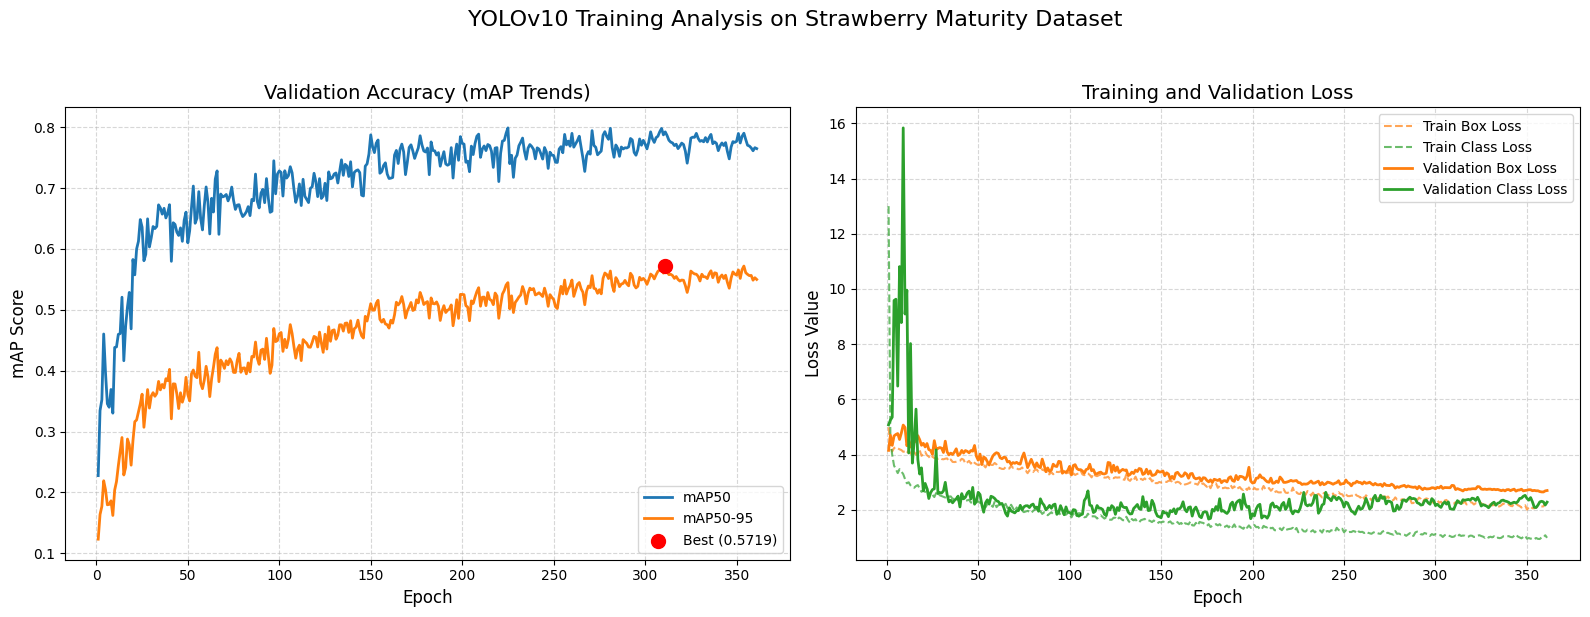

: 

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import sys
import numpy as np

# --- Configuration ---
RUNS_DIR = 'runs/detect'
COL_EPOCH = 'epoch'
COL_M_AP50 = 'metrics/mAP50(B)'
COL_M_AP50_95 = 'metrics/mAP50-95(B)'
COL_P = 'metrics/precision(B)'
COL_R = 'metrics/recall(B)'
COL_TRAIN_LOSS = 'train/box_loss'
COL_VAL_LOSS = 'val/box_loss'


def find_latest_train_dir(base_dir):
    """Automatically finds the path to the most recent training run directory."""
    search_path = os.path.join(base_dir, 'train*')
    dirs = glob.glob(search_path)
    if not dirs:
        return None
    # Sort by modification time to get the latest folder
    return max(dirs, key=os.path.getmtime)

def analyze_and_plot_results():
    latest_dir = find_latest_train_dir(RUNS_DIR)
    
    if latest_dir is None:
        print(f"ERROR: No training run folder found in '{RUNS_DIR}'.")
        return

    csv_path = os.path.join(latest_dir, 'results.csv')
    
    if not os.path.exists(csv_path):
        print(f"ERROR: 'results.csv' not found in {latest_dir}. Please ensure training has finished or run folder exists.")
        return

    print(f"--- Analyzing Results from: {os.path.basename(latest_dir)} ---")
    
    # 1. Load Data and Clean Columns
    try:
        df = pd.read_csv(csv_path)
        # Strip potential leading/trailing spaces from column names (Crucial for Ultralytics CSV)
        df.columns = df.columns.str.strip()
    except Exception as e:
        print(f"ERROR: Failed to read CSV. Detail: {e}")
        return

    # 2. Find Best Model Checkpoint (Highest mAP50-95)
    if COL_M_AP50_95 not in df.columns:
        print(f"ERROR: Required column '{COL_M_AP50_95}' not found.")
        return

    # Find the row with the highest mAP50-95
    best_idx = df[COL_M_AP50_95].idxmax()
    best_epoch_data = df.loc[best_idx]
    
    # --- REPORT SUMMARY ---
    print("\n" + "="*70)
    print("           YOLOv10 TRAINING PERFORMANCE SUMMARY (FROM CSV)")
    print("="*70)
    print(f"| RUN DIRECTORY: {os.path.basename(latest_dir)}")
    print("-" * 70)
    print(f"| BEST CHECKPOINT (Epoch {int(best_epoch_data[COL_EPOCH])})")
    print(f"|  - mAP50-95 (Overall Quality): {best_epoch_data[COL_M_AP50_95]:.4f}")
    print(f"|  - mAP50 (Detection Quality):  {best_epoch_data[COL_M_AP50]:.4f}")
    print(f"|  - Precision (Accuracy):       {best_epoch_data[COL_P]:.4f}")
    print(f"|  - Recall (Completeness):      {best_epoch_data[COL_R]:.4f}")
    print("="*70)
    
    # 3. Plotting Curves (2-Panel Layout)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Panel 1: Accuracy Curves ---
    axes[0].plot(df[COL_EPOCH], df[COL_M_AP50], label='mAP50', linewidth=2)
    axes[0].plot(df[COL_EPOCH], df[COL_M_AP50_95], label='mAP50-95', linewidth=2)
    axes[0].scatter(best_epoch_data[COL_EPOCH], best_epoch_data[COL_M_AP50_95], 
                    color='red', s=100, zorder=5, label=f'Best ({best_epoch_data[COL_M_AP50_95]:.4f})')
    
    axes[0].set_title('Validation Accuracy (mAP Trends)', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('mAP Score', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='lower right')

    # --- Panel 2: Loss Curves (Training & Validation) ---
    # Training Losses
    axes[1].plot(df[COL_EPOCH], df['train/box_loss'], label='Train Box Loss', linestyle='--', color='tab:orange', alpha=0.7)
    axes[1].plot(df[COL_EPOCH], df['train/cls_loss'], label='Train Class Loss', linestyle='--', color='tab:green', alpha=0.7)
    
    # Validation Losses
    axes[1].plot(df[COL_EPOCH], df['val/box_loss'], label='Validation Box Loss', color='tab:orange', linewidth=2)
    axes[1].plot(df[COL_EPOCH], df['val/cls_loss'], label='Validation Class Loss', color='tab:green', linewidth=2)

    axes[1].set_title('Training and Validation Loss', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss Value', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper right')

    plt.suptitle("YOLOv10 Training Analysis on Strawberry Maturity Dataset", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
    plt.show()

# --- Execution ---
analyze_and_plot_results()

--- Analyzing Results from: train8 ---

           YOLOv10s TRAINING PERFORMANCE SUMMARY (FROM CSV)
| RUN DIRECTORY: train8
----------------------------------------------------------------------
| BEST CHECKPOINT (Epoch 311)
|  - mAP50-95 (Overall Quality): 0.5719
|  - mAP50 (Detection Quality):  0.7922
|  - Precision (Accuracy):       0.8097
|  - Recall (Completeness):      0.7140


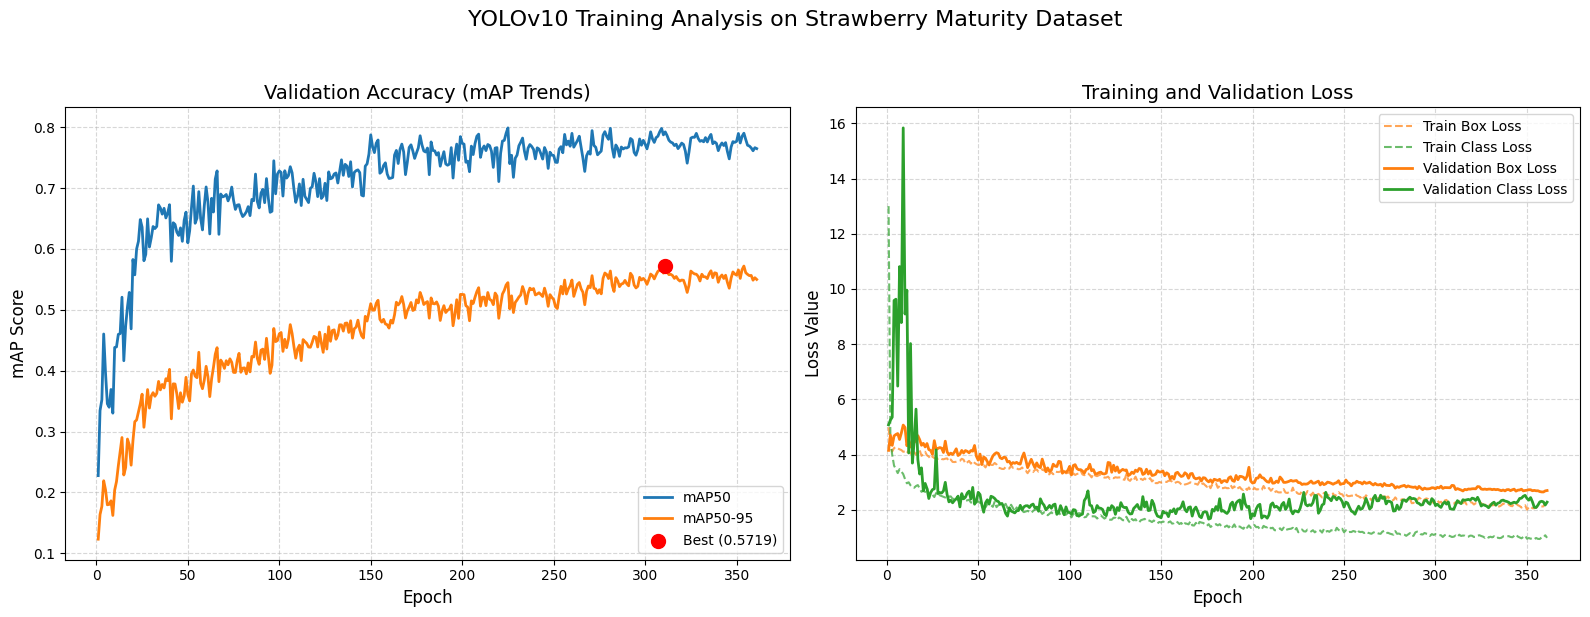

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import sys
import numpy as np

# --- Configuration ---
RUNS_DIR = 'runs/detect'

# Define all column names needed (standard Ultralytics outputs)
COL_EPOCH = 'epoch'
COL_M_AP50 = 'metrics/mAP50(B)'
COL_M_AP50_95 = 'metrics/mAP50-95(B)'
COL_P = 'metrics/precision(B)'
COL_R = 'metrics/recall(B)'
COL_TRAIN_LOSS = 'train/box_loss'
COL_VAL_LOSS = 'val/box_loss'


def find_latest_train_dir(base_dir):
    """Automatically finds the path to the most recent training run directory."""
    search_path = os.path.join(base_dir, 'train*')
    dirs = glob.glob(search_path)
    if not dirs:
        return None
    # Sort by modification time to get the latest folder
    return max(dirs, key=os.path.getmtime)

def analyze_and_plot_results():
    latest_dir = find_latest_train_dir(RUNS_DIR)
    
    if latest_dir is None:
        print(f"ERROR: No training run folder found in '{RUNS_DIR}'.")
        return

    csv_path = os.path.join(latest_dir, 'results.csv')
    
    if not os.path.exists(csv_path):
        print(f"ERROR: 'results.csv' not found in {latest_dir}. Please ensure training has finished or run folder exists.")
        return

    print(f"--- Analyzing Results from: {os.path.basename(latest_dir)} ---")
    
    # 1. Load Data and Clean Columns
    try:
        df = pd.read_csv(csv_path)
        # Strip potential leading/trailing spaces from column names (Crucial for Ultralytics CSV)
        df.columns = df.columns.str.strip()
    except Exception as e:
        print(f"ERROR: Failed to read CSV. Detail: {e}")
        return

    # 2. Find Best Model Checkpoint (Highest mAP50-95)
    if COL_M_AP50_95 not in df.columns:
        print(f"ERROR: Required column '{COL_M_AP50_95}' not found.")
        return

    # Find the row with the highest mAP50-95
    best_idx = df[COL_M_AP50_95].idxmax()
    best_epoch_data = df.loc[best_idx]
    
    # --- REPORT SUMMARY ---
    print("\n" + "="*70)
    print("           YOLOv10s TRAINING PERFORMANCE SUMMARY (FROM CSV)")
    print("="*70)
    print(f"| RUN DIRECTORY: {os.path.basename(latest_dir)}")
    print("-" * 70)
    print(f"| BEST CHECKPOINT (Epoch {int(best_epoch_data[COL_EPOCH])})")
    print(f"|  - mAP50-95 (Overall Quality): {best_epoch_data[COL_M_AP50_95]:.4f}")
    print(f"|  - mAP50 (Detection Quality):  {best_epoch_data[COL_M_AP50]:.4f}")
    print(f"|  - Precision (Accuracy):       {best_epoch_data[COL_P]:.4f}")
    print(f"|  - Recall (Completeness):      {best_epoch_data[COL_R]:.4f}")
    print("="*70)
    
    # 3. Plotting Curves (2-Panel Layout)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Panel 1: Accuracy Curves ---
    axes[0].plot(df[COL_EPOCH], df[COL_M_AP50], label='mAP50', linewidth=2)
    axes[0].plot(df[COL_EPOCH], df[COL_M_AP50_95], label='mAP50-95', linewidth=2)
    axes[0].scatter(best_epoch_data[COL_EPOCH], best_epoch_data[COL_M_AP50_95], 
                    color='red', s=100, zorder=5, label=f'Best ({best_epoch_data[COL_M_AP50_95]:.4f})')
    
    axes[0].set_title('Validation Accuracy (mAP Trends)', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('mAP Score', fontsize=12)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='lower right')

    # --- Panel 2: Loss Curves (Training & Validation) ---
    # Training Losses
    axes[1].plot(df[COL_EPOCH], df['train/box_loss'], label='Train Box Loss', linestyle='--', color='tab:orange', alpha=0.7)
    axes[1].plot(df[COL_EPOCH], df['train/cls_loss'], label='Train Class Loss', linestyle='--', color='tab:green', alpha=0.7)
    
    # Validation Losses
    axes[1].plot(df[COL_EPOCH], df['val/box_loss'], label='Validation Box Loss', color='tab:orange', linewidth=2)
    axes[1].plot(df[COL_EPOCH], df['val/cls_loss'], label='Validation Class Loss', color='tab:green', linewidth=2)

    axes[1].set_title('Training and Validation Loss', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss Value', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend(loc='upper right')

    plt.suptitle("YOLOv10 Training Analysis on Strawberry Maturity Dataset", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
    plt.show()

# --- Execution ---
analyze_and_plot_results()

📂 正在展示來自 [ runs/detect\train8 ] 的結果圖表



### 📈 訓練過程總覽 (損失 & mAP 曲線)

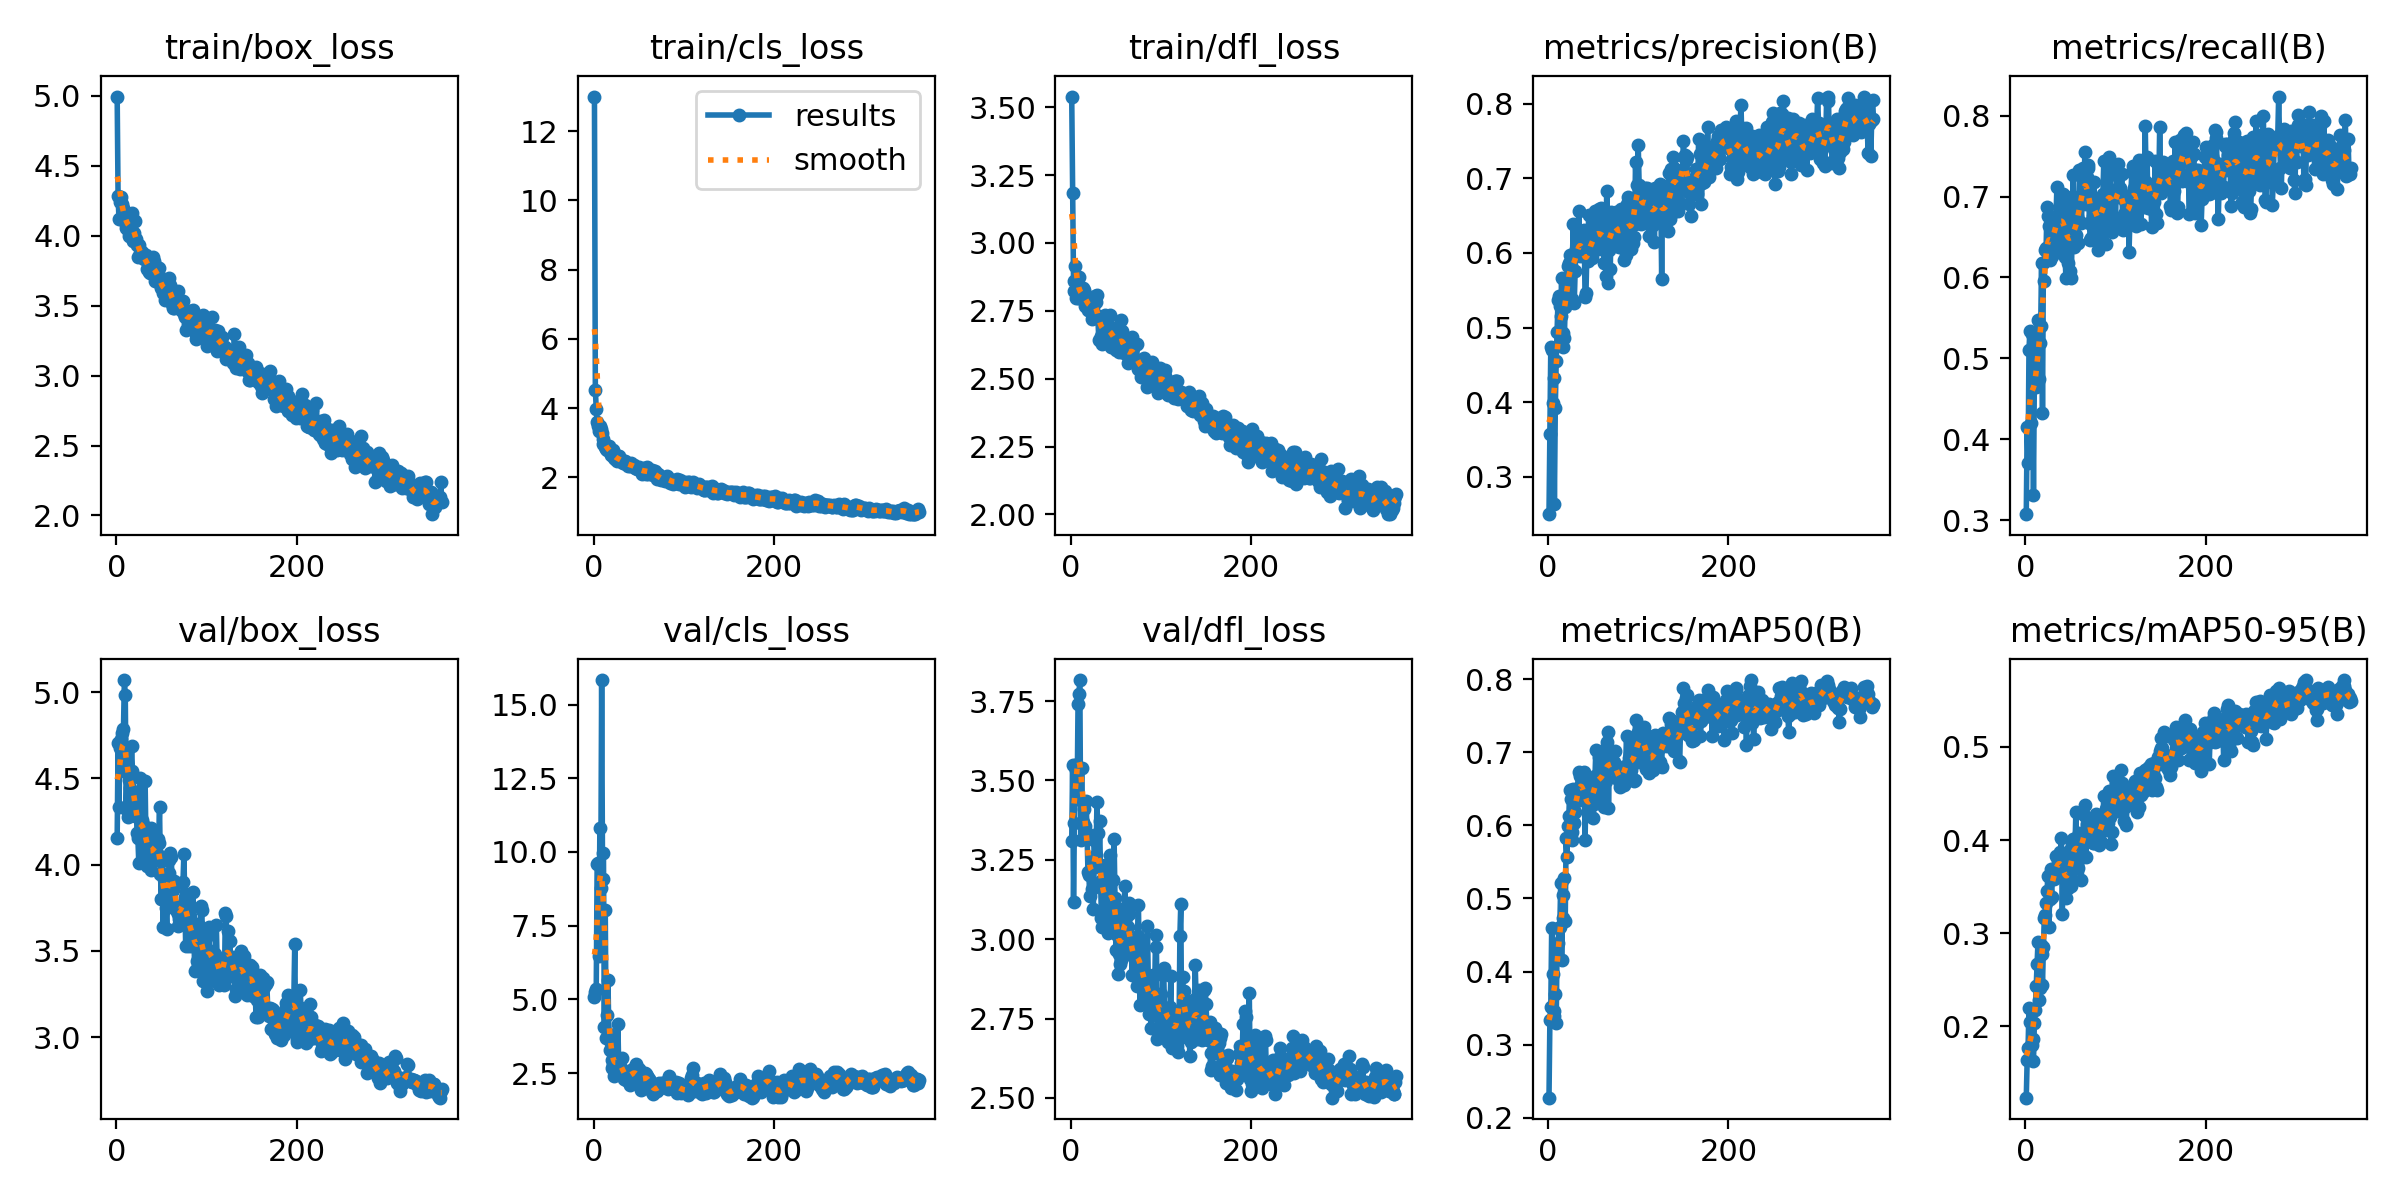


------------------------------------------------------------



### 🟦 混淆矩陣 (正規化) - 查看類別混淆情況

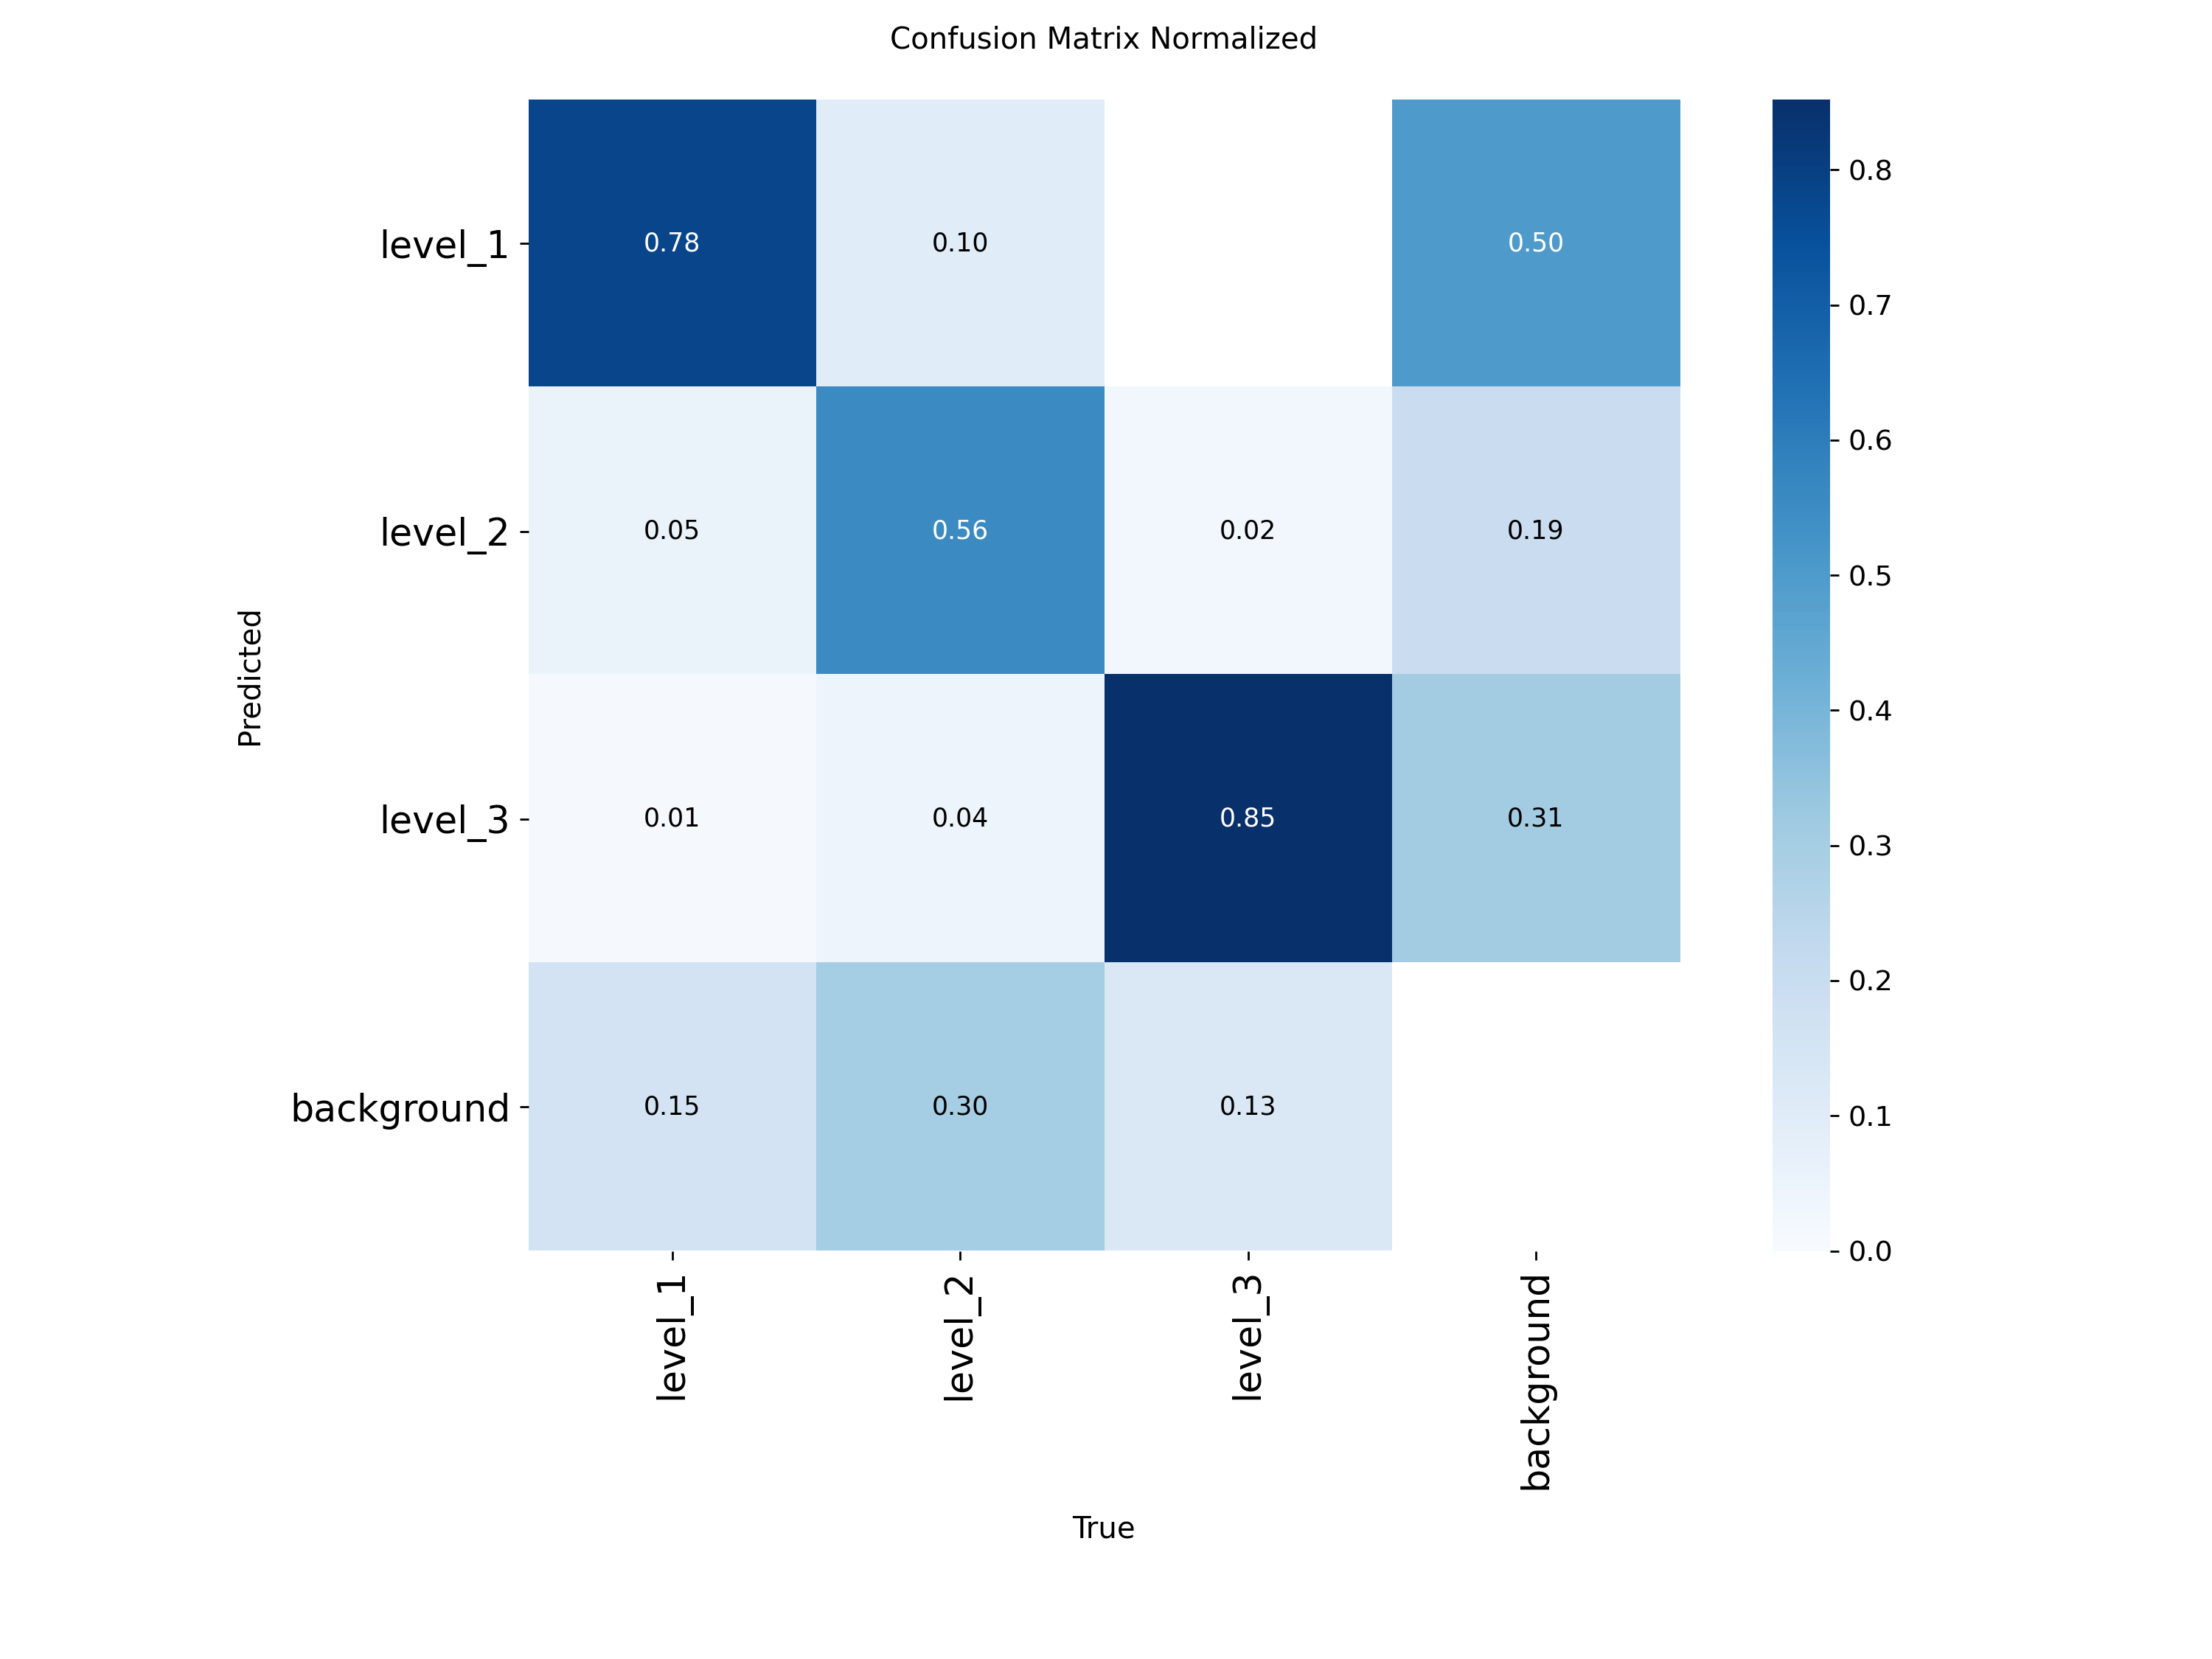


------------------------------------------------------------



### 🟦 混淆矩陣 (原始數量)

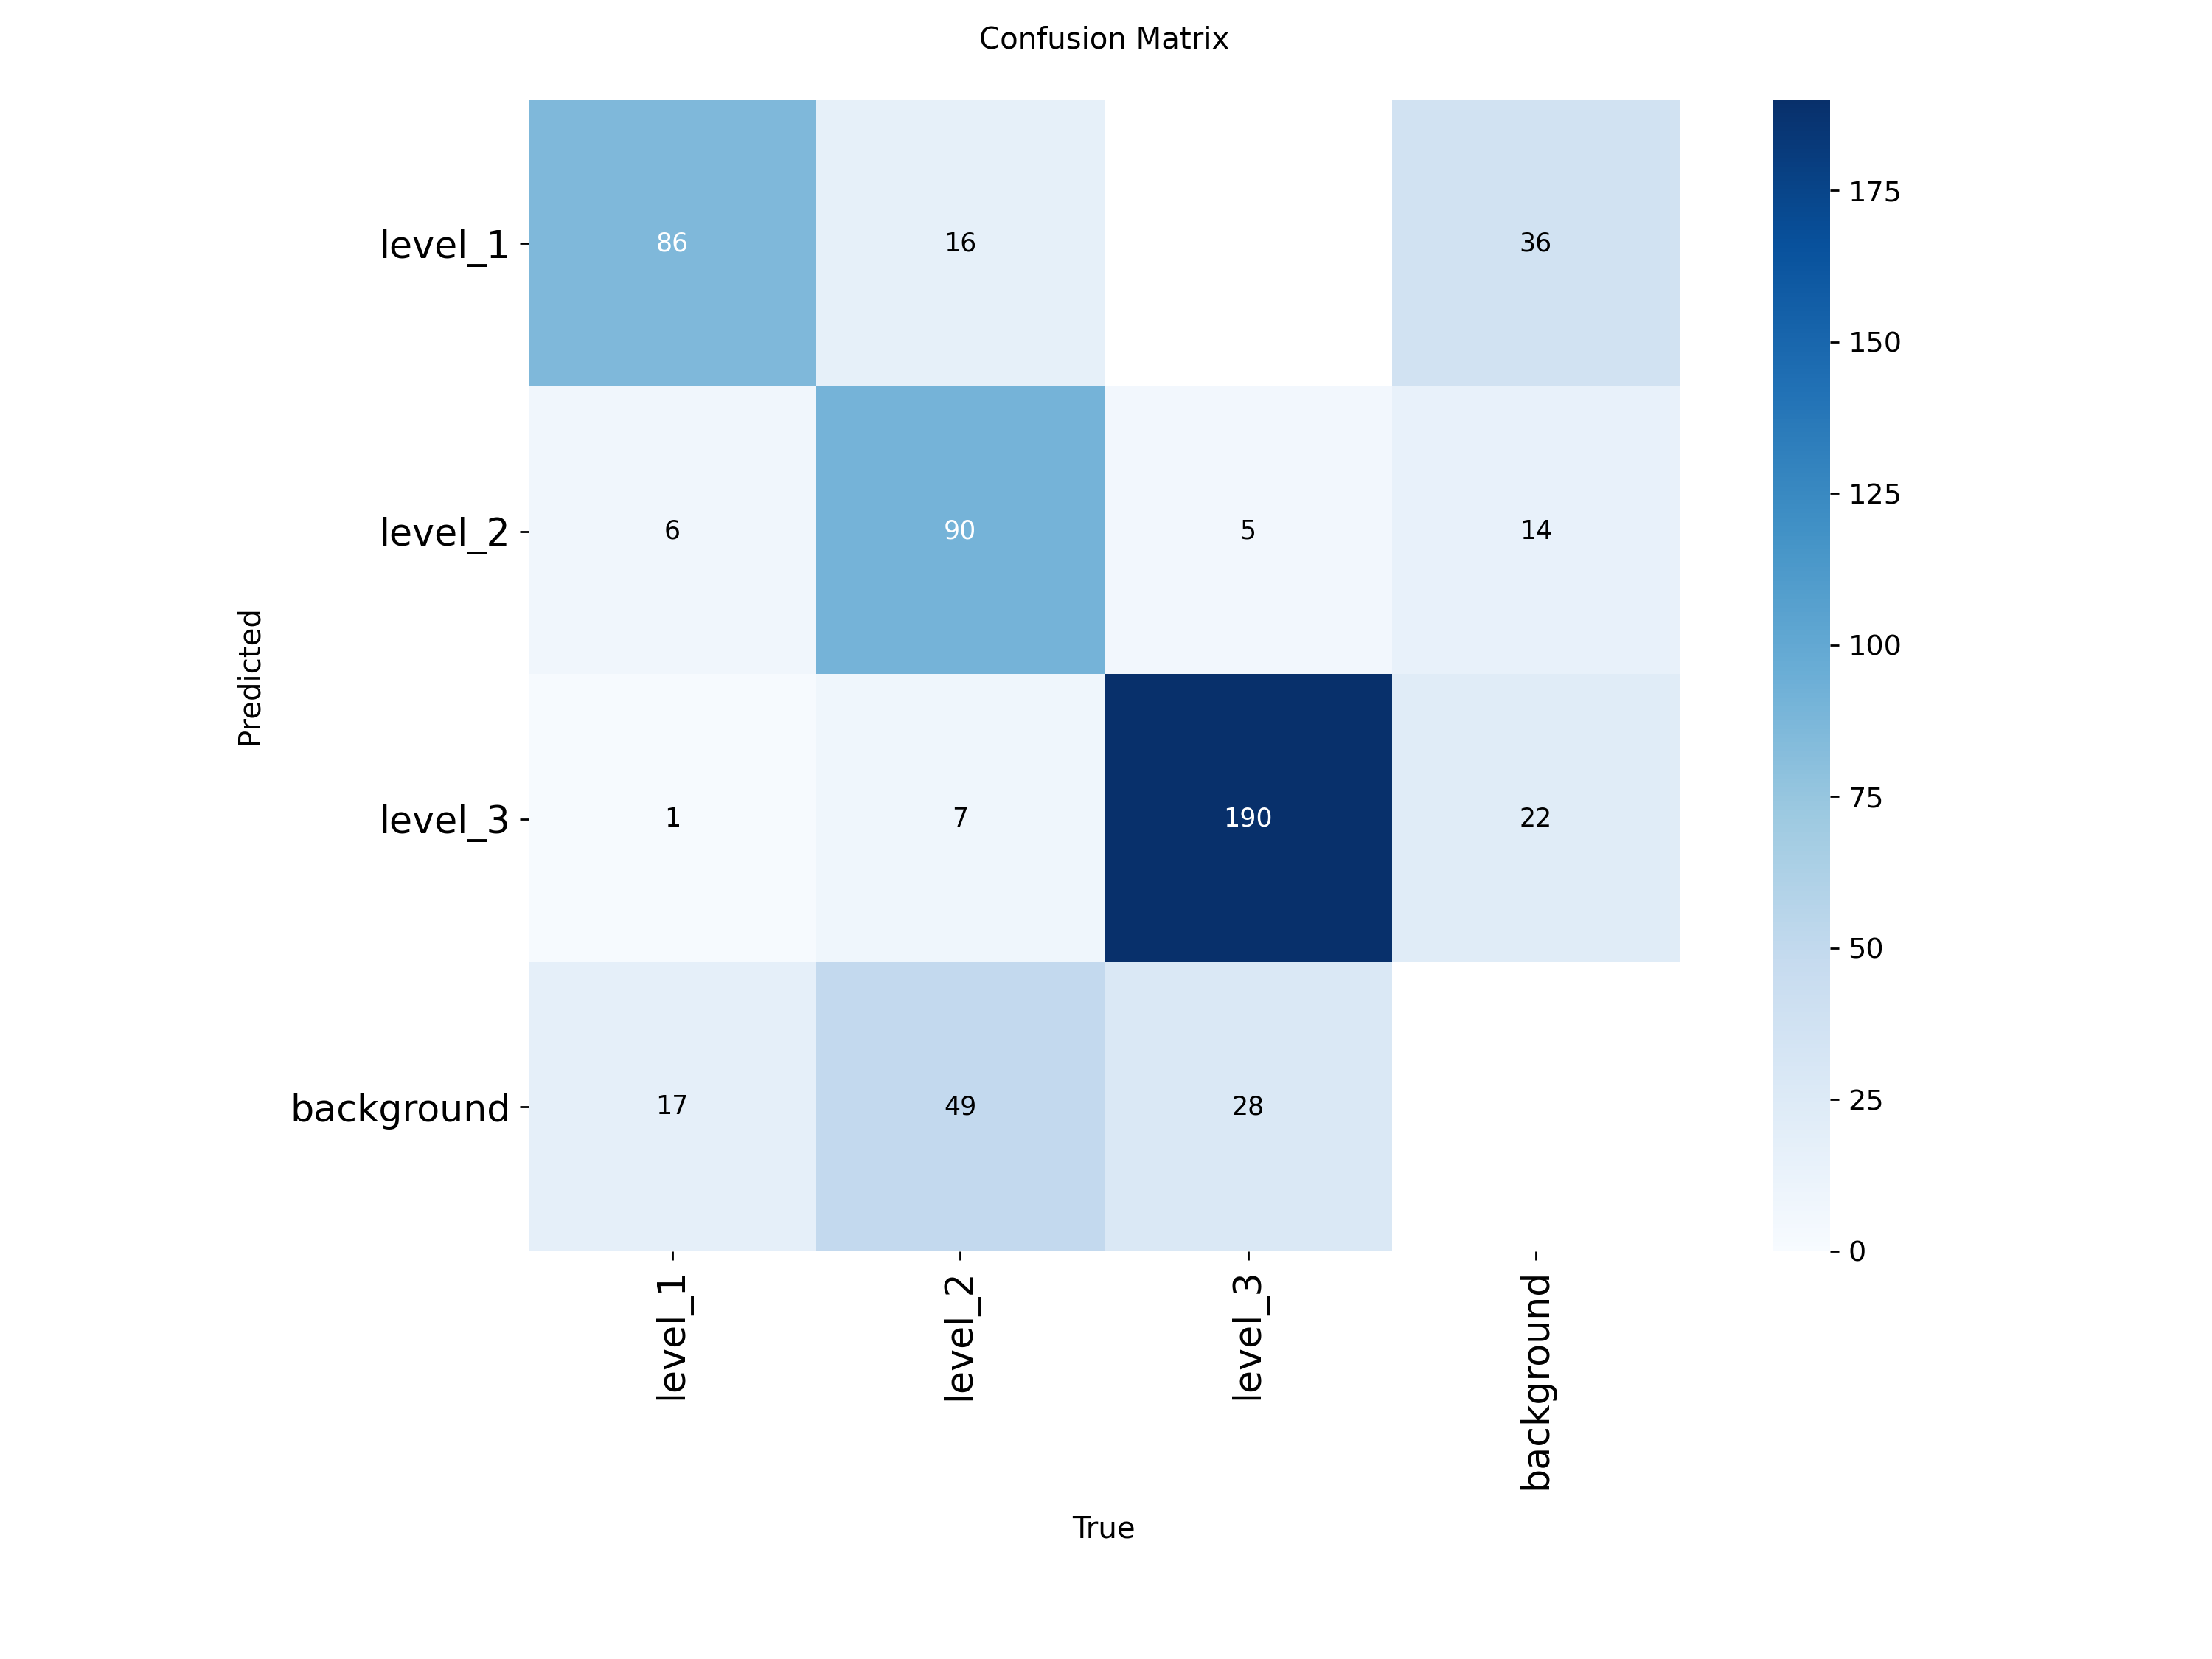


------------------------------------------------------------



### 🖼️ 驗證集預測範例 (Batch 0) - 模型實際看到的樣子

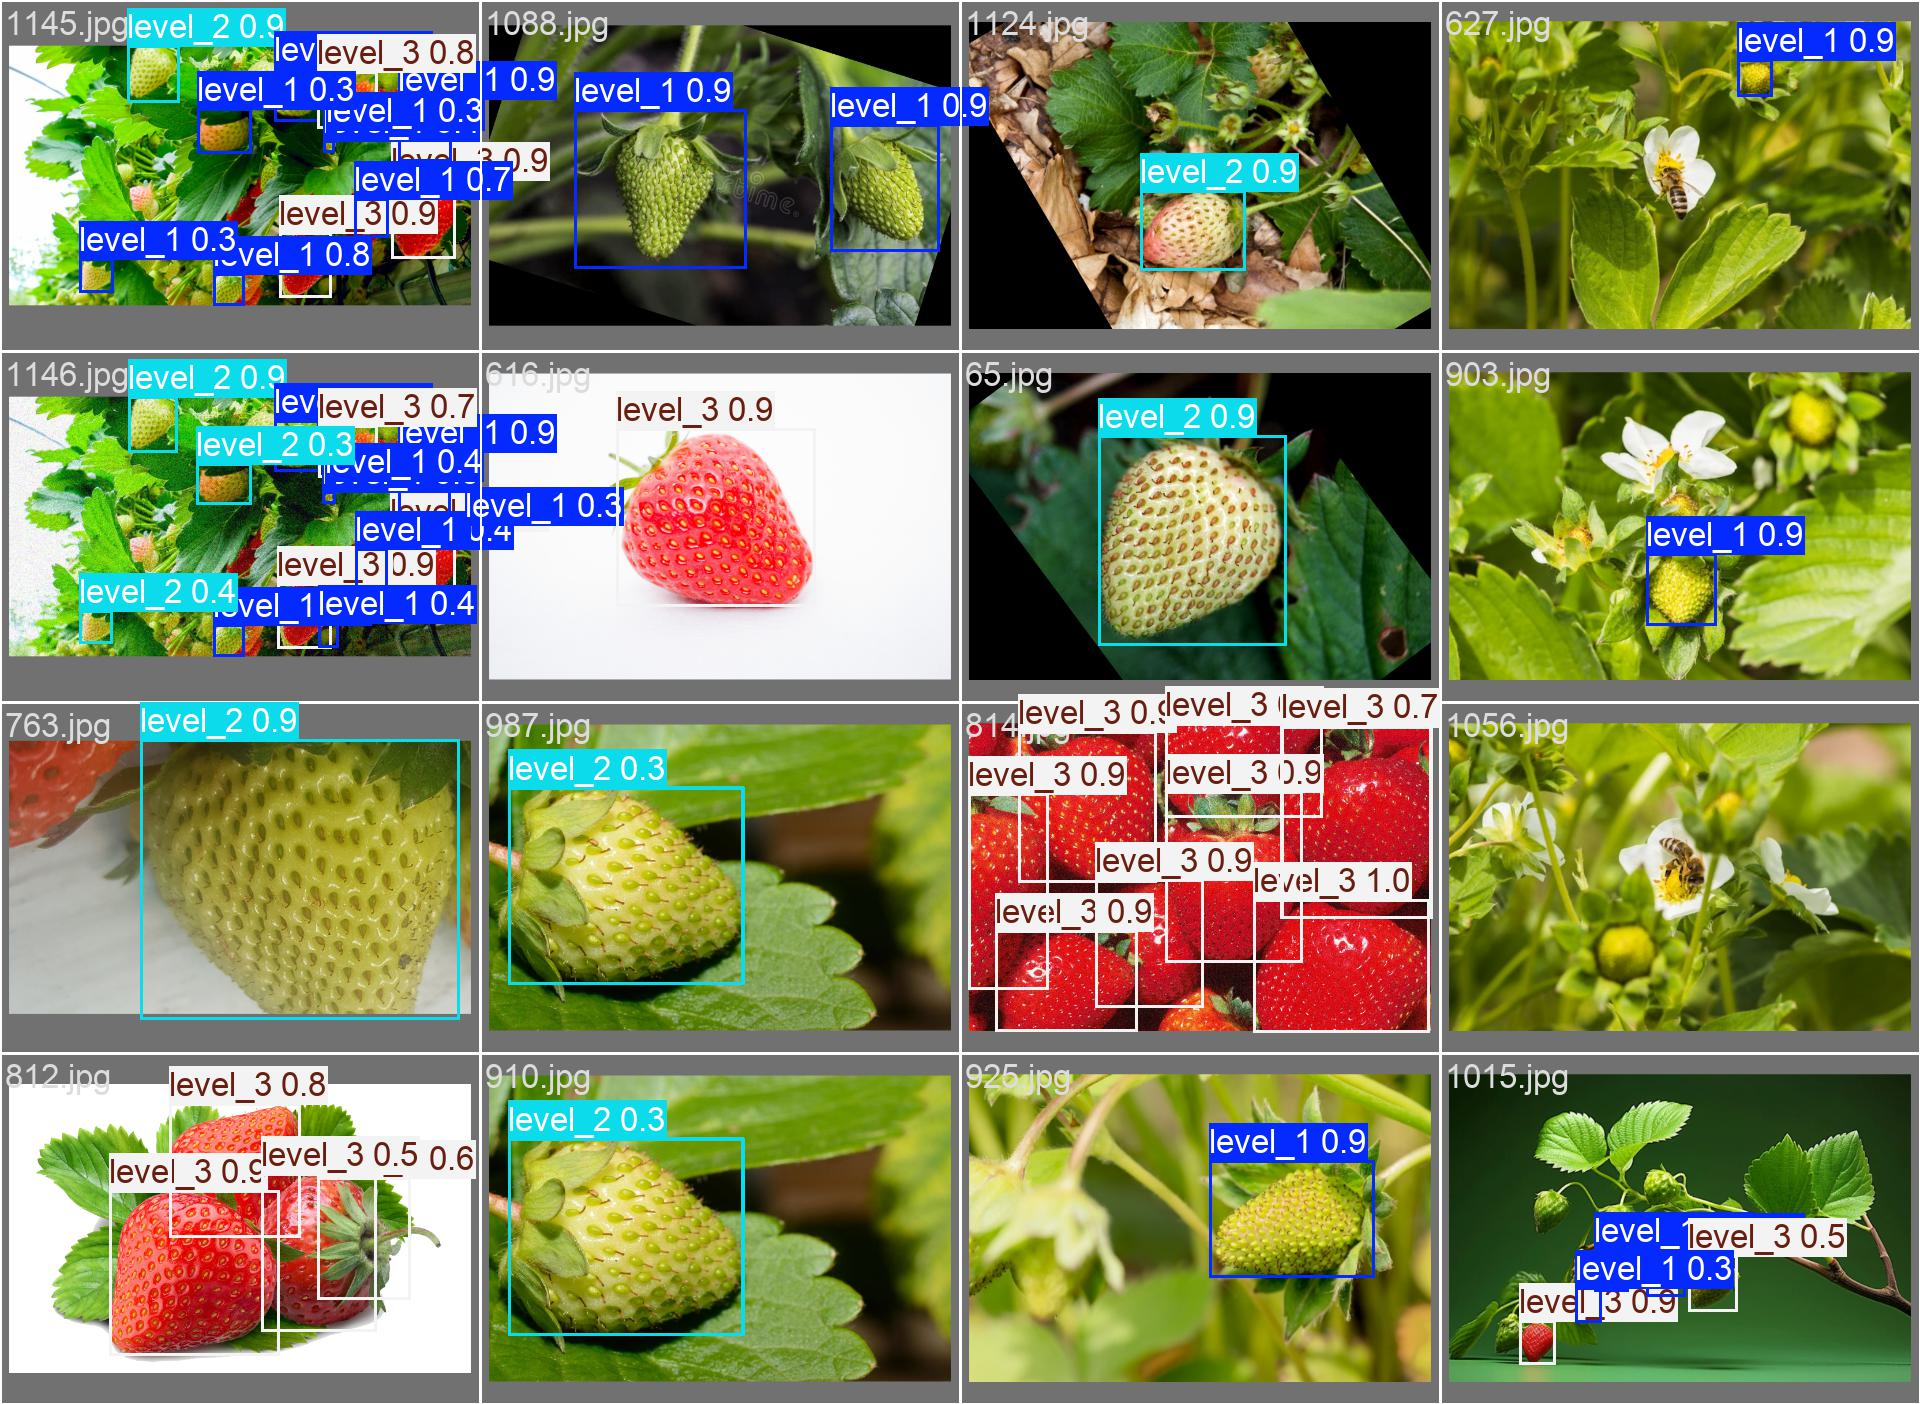


------------------------------------------------------------



### 🏷️ 驗證集真實標籤 (Batch 0) - 正確答案

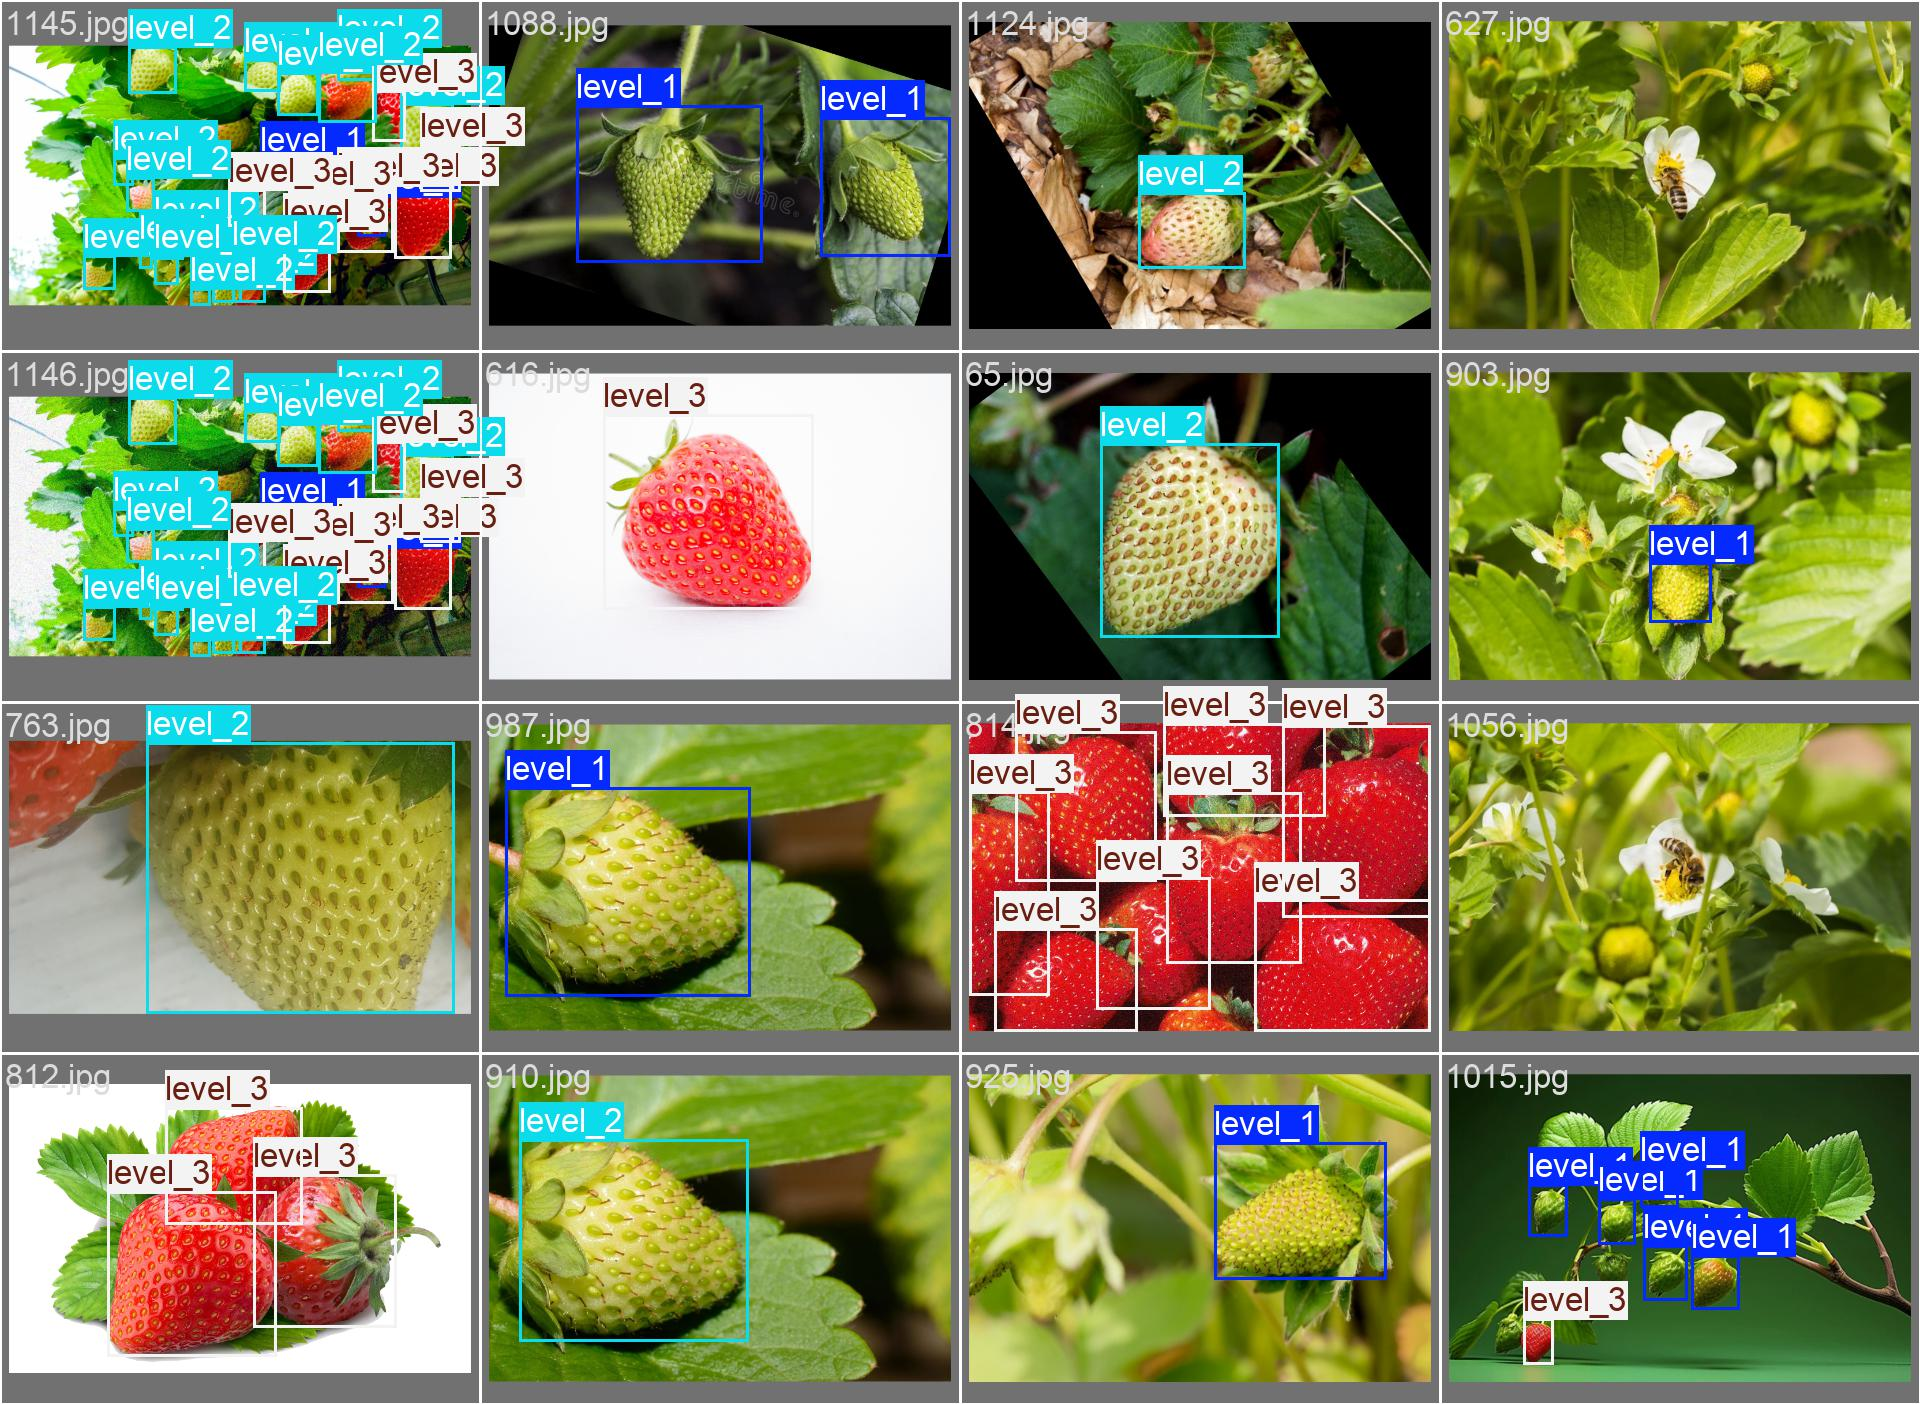


------------------------------------------------------------



### 🖼️ 驗證集預測範例 (Batch 1)

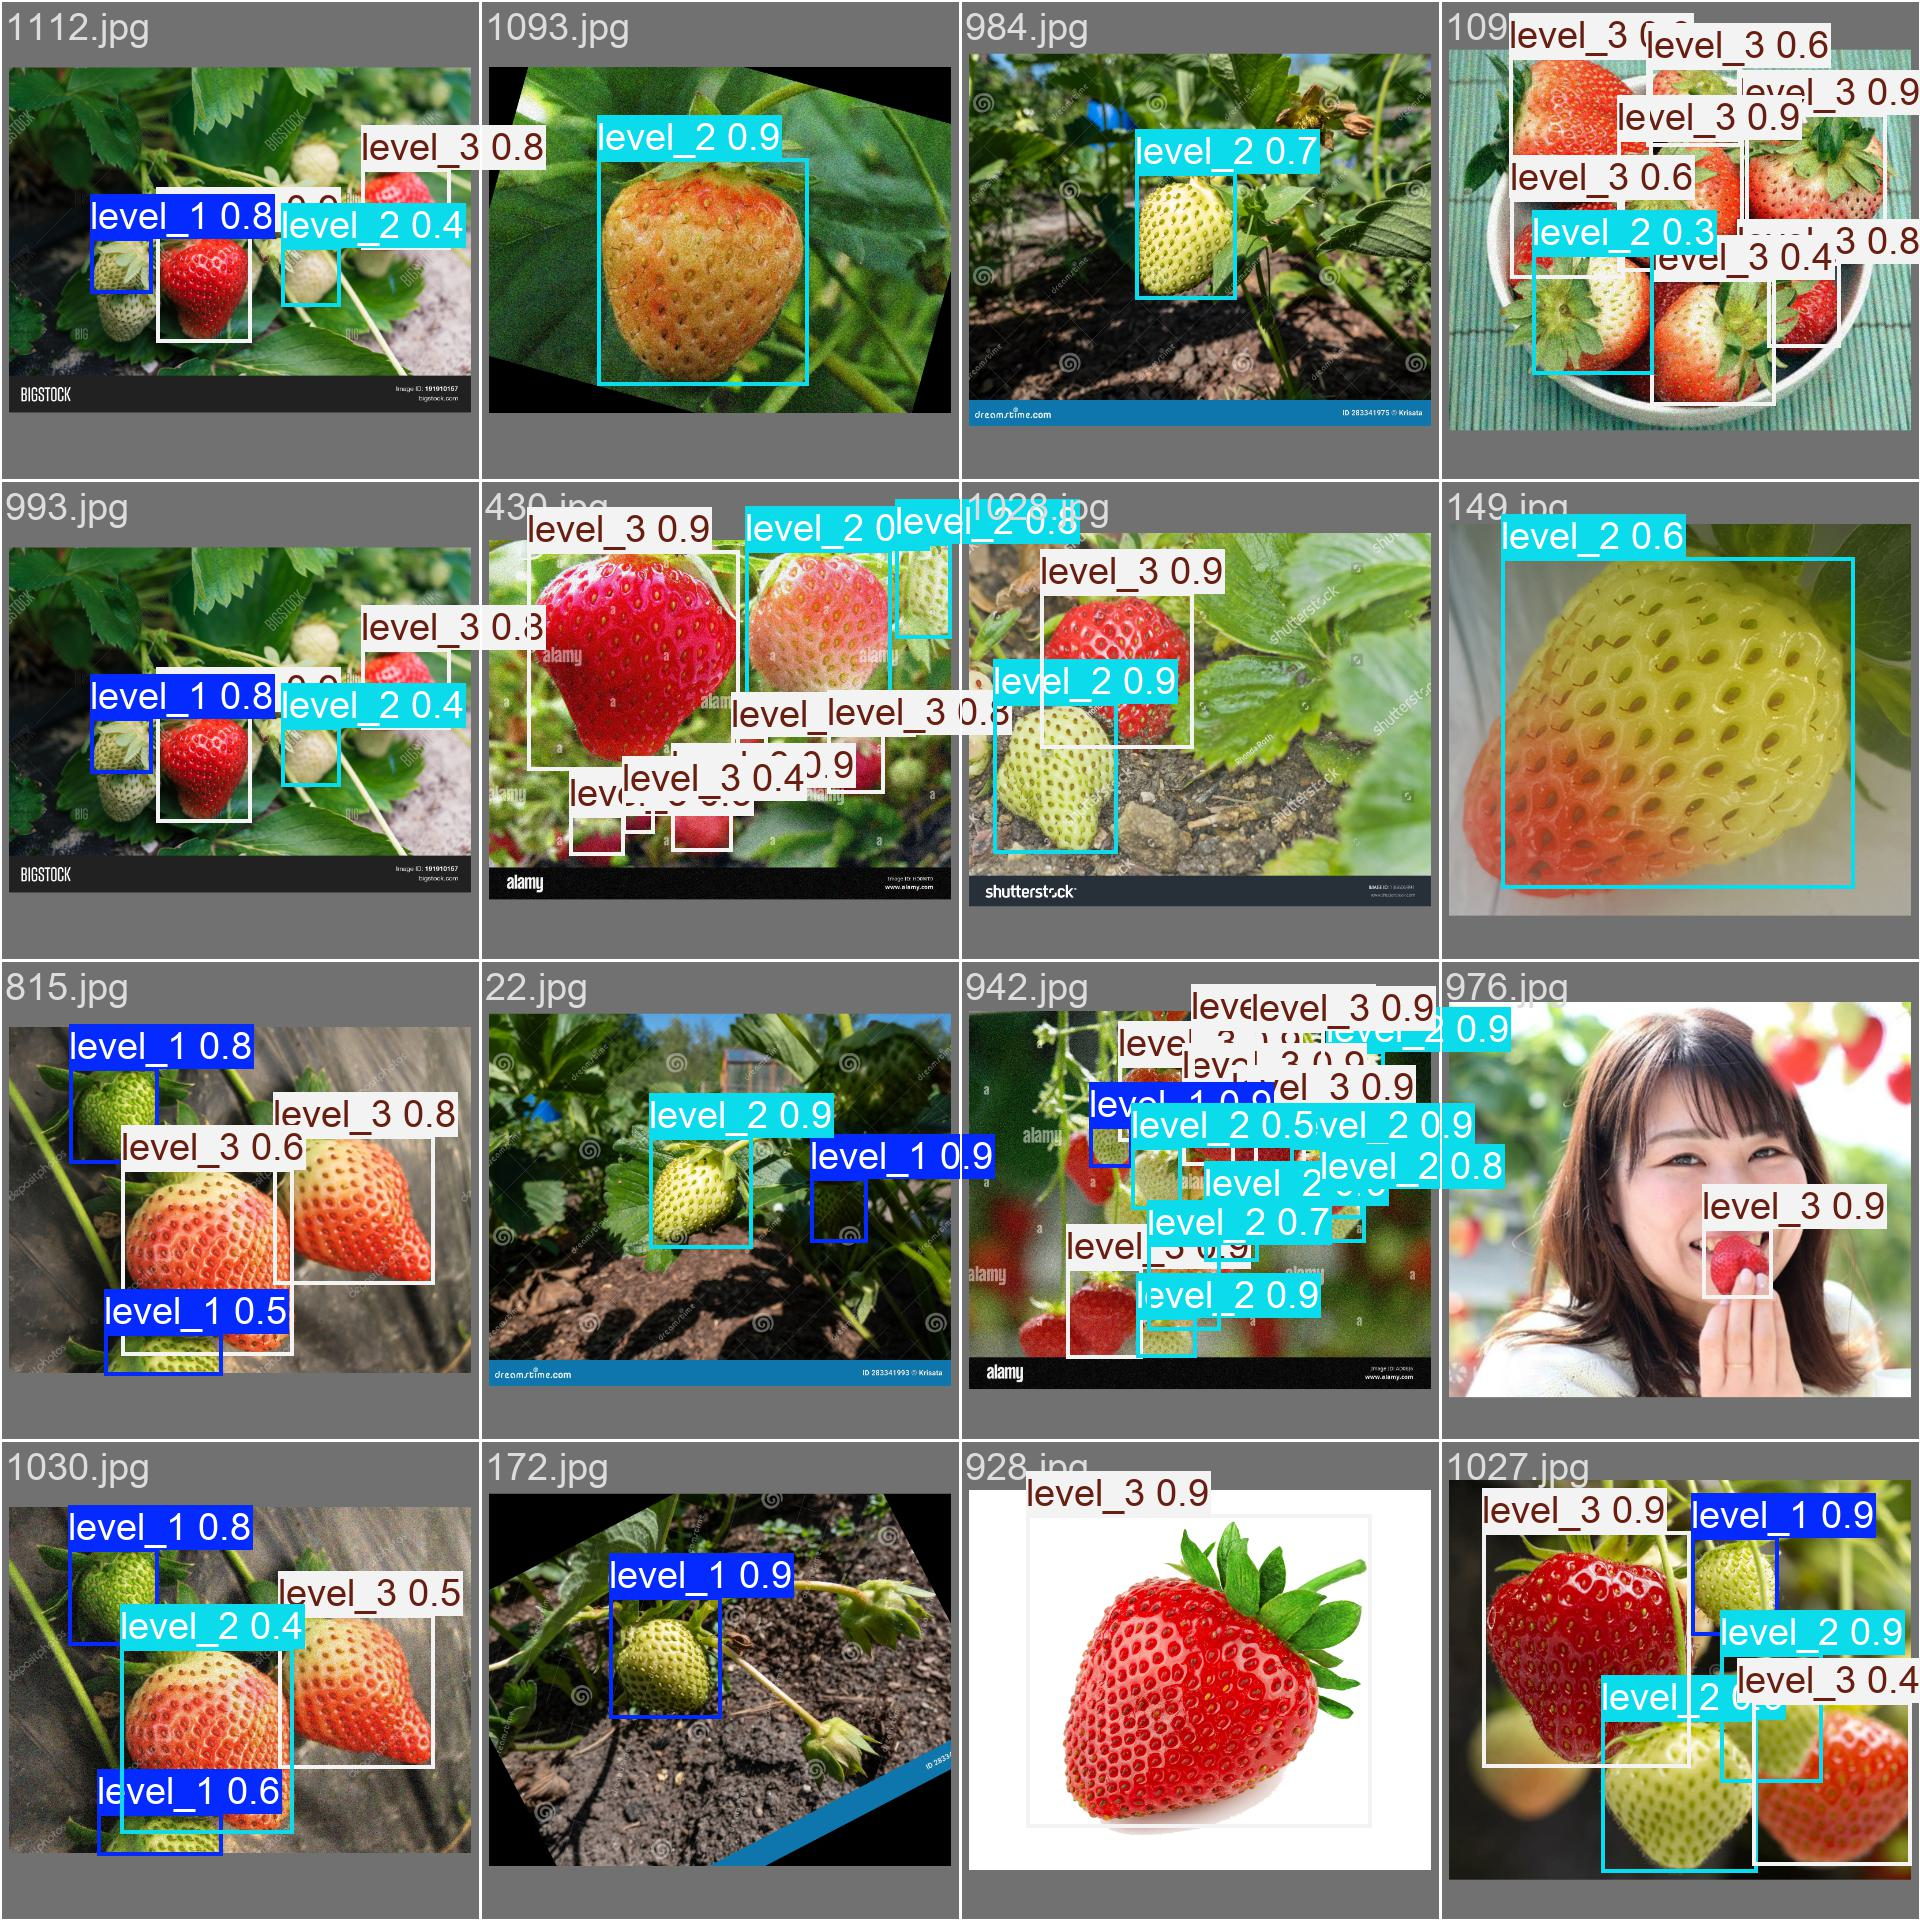


------------------------------------------------------------



In [1]:
import os
import glob
from IPython.display import display, Image, Markdown

# --- 設定：訓練結果目錄 ---
RUNS_DIR = 'runs/detect'

def find_latest_train_dir(base_dir):
    """自動尋找最新的訓練資料夾"""
    search_path = os.path.join(base_dir, 'train*')
    dirs = glob.glob(search_path)
    if not dirs:
        return None
    # 根據修改時間排序，最新的在最後
    return max(dirs, key=os.path.getmtime)

def show_yolo_plots():
    latest_dir = find_latest_train_dir(RUNS_DIR)
    
    if not latest_dir:
        print(f"❌ 找不到訓練資料夾於 {RUNS_DIR}")
        return

    print(f"📂 正在展示來自 [ {latest_dir} ] 的結果圖表\n")

    # 想要顯示的圖表清單 (依照優先順序)
    images_to_show = {
        "results.png": "📈 訓練過程總覽 (損失 & mAP 曲線)",
        "confusion_matrix_normalized.png": "🟦 混淆矩陣 (正規化) - 查看類別混淆情況",
        "confusion_matrix.png": "🟦 混淆矩陣 (原始數量)",
        "F1_curve.png": "🎯 F1-Score 曲線 (準確與召回的平衡)",
        "PR_curve.png": "📉 Precision-Recall 曲線",
        "val_batch0_pred.jpg": "🖼️ 驗證集預測範例 (Batch 0) - 模型實際看到的樣子",
        "val_batch0_labels.jpg": "🏷️ 驗證集真實標籤 (Batch 0) - 正確答案",
        "val_batch1_pred.jpg": "🖼️ 驗證集預測範例 (Batch 1)",
    }

    found_any = False
    for filename, description in images_to_show.items():
        img_path = os.path.join(latest_dir, filename)
        
        if os.path.exists(img_path):
            found_any = True
            # 使用 Markdown 顯示標題，讓排版好看一點
            display(Markdown(f"### {description}"))
            display(Image(filename=img_path, width=800)) # width 可自行調整
            print("\n" + "-"*60 + "\n")
    
    if not found_any:
        print("⚠️ 警告：在這個資料夾中找不到上述任何一張圖表。請確認訓練是否已完成至少一個 Epoch。")

# --- 執行 ---
show_yolo_plots()

In [3]:
#使用 Python 腳本自動排名各次訓練結果
import os
import pandas as pd
from glob import glob

# 設定您的訓練結果路徑
ROOT_DIR = 'runs/detect'

def compare_training_results():
    print(f"🔍 正在掃描 {ROOT_DIR} 下的所有訓練紀錄...\n")
    
    summary_data = []
    
    # 搜尋所有 train 開頭的資料夾
    search_path = os.path.join(ROOT_DIR, 'train*')
    folders = glob(search_path)
    
    if not folders:
        print("❌ 找不到任何訓練資料夾，請確認路徑是否正確。")
        return

    for folder in folders:
        csv_path = os.path.join(folder, 'results.csv')
        
        # 檢查是否存在 results.csv
        if os.path.exists(csv_path):
            try:
                # 讀取 CSV
                df = pd.read_csv(csv_path)
                
                # 清理欄位名稱 (YOLO 的 CSV 欄位名稱常帶有空格)
                df.columns = [c.strip() for c in df.columns]
                
                # 找出 mAP50-95 最高的那一列 (代表該次訓練的最佳表現)
                # 欄位通常是 'metrics/mAP50-95(B)'
                best_idx = df['metrics/mAP50-95(B)'].idxmax()
                best_epoch = df.iloc[best_idx]
                
                folder_name = os.path.basename(folder)
                
                summary_data.append({
                    'Folder (資料夾)': folder_name,
                    'Epochs (總輪數)': len(df),
                    'Best mAP50-95': best_epoch['metrics/mAP50-95(B)'], # 綜合指標 (最重要)
                    'Best mAP50': best_epoch['metrics/mAP50(B)'],       # 偵測成功率
                    'Best Precision': best_epoch['metrics/precision(B)'],
                    'Best Recall': best_epoch['metrics/recall(B)']
                })
            except Exception as e:
                print(f"⚠️ 無法讀取 {folder}: {e}")

    # 轉為 DataFrame 並排序
    if summary_data:
        result_df = pd.read_csv(csv_path) # 修正: 這裡不需要重讀，直接用 summary_data 建立 DataFrame
        result_df = pd.DataFrame(summary_data)
        
        # 依照 mAP50-95 由高到低排序
        result_df = result_df.sort_values(by='Best mAP50-95', ascending=False).reset_index(drop=True)
        
        print("-" * 80)
        print("🏆 訓練結果排行榜 (依照 mAP50-95 排序)")
        print("-" * 80)
        print(result_df.to_string(index=False))
        print("-" * 80)
        
        # 告訴使用者最好的模型在哪
        best_run = result_df.iloc[0]
        print(f"\n✅ 最強模型位於: {best_run['Folder (資料夾)']}")
        print(f"   mAP50-95: {best_run['Best mAP50-95']:.4f}")
        print(f"   mAP50   : {best_run['Best mAP50']:.4f}")
        print(f"\n💡 請使用此權重檔進行口試展示: runs/detect/{best_run['Folder (資料夾)']}/weights/best.pt")
        
    else:
        print("❌ 沒有讀取到有效的訓練數據。")

if __name__ == '__main__':
    compare_training_results()

🔍 正在掃描 runs/detect 下的所有訓練紀錄...

--------------------------------------------------------------------------------
🏆 訓練結果排行榜 (依照 mAP50-95 排序)
--------------------------------------------------------------------------------
Folder (資料夾)  Epochs (總輪數)  Best mAP50-95  Best mAP50  Best Precision  Best Recall
      train8           361        0.57191     0.79223         0.80966      0.71401
      train0           145        0.55485     0.80463         0.77097      0.72657
      train1           104        0.55173     0.79066         0.76437      0.71306
      train7           402        0.54199     0.78192         0.68067      0.77116
      train4           181        0.50117     0.72338         0.64828      0.72490
      train2            48        0.46524     0.71958         0.64572      0.75316
--------------------------------------------------------------------------------

✅ 最強模型位於: train8
   mAP50-95: 0.5719
   mAP50   : 0.7922

💡 請使用此權重檔進行口試展示: runs/detect/train8/weights/best.pt
